['Portenta', 'nano', 'orin', 'rbp4', 'rbp5']

In [120]:
for path in path_ls:
    data_ls = sorted(os.listdir(f'./{path}'))
    data_dict[path] = {}
    for data in data_ls:
        data_dict[path][data] = pd.read_csv(f'./{path}/{data}')

data_dict

{'Portenta': {'Portenta_tflite.csv':               0          1          3          4          6          7  \
  0     33.381440 -94.929860 -31.561827  67.949844  61.204437 -54.869335   
  1    -28.463003   2.524866  80.478230  89.652214 -44.827100  80.793015   
  2    -88.039970 -13.227165 -49.662334  62.459755  53.099747   5.650627   
  3     90.250110  99.304985 -82.832886 -75.337975 -85.579155 -94.265480   
  4    -17.023457  34.695500   1.025011  83.458660  93.074470  44.745056   
  ...         ...        ...        ...        ...        ...        ...   
  9995 -19.042177  17.697973 -12.094292 -51.694046 -45.294815  25.088392   
  9996 -82.162445  10.696586   2.880204 -46.586002  85.521680 -92.036150   
  9997   2.044212  94.413240  13.454857  14.408174  37.621548 -95.669495   
  9998  52.919190  90.435260   4.891659  22.177473 -75.067604 -64.828224   
  9999  22.090538  17.805012 -34.323150 -27.451689 -86.223785 -40.447533   
  
                9         10         12         13

In [121]:
df_ls = data_dict['orin']
df_ls.keys()

dict_keys(['orin_tensorRT.csv', 'orin_tflite.csv', 'orin_tflite_fp16.csv', 'orin_tflite_int8.csv', 'orin_torch.csv'])

In [122]:
# data_dict 내용 확인
print("data_dict 키들:", list(data_dict.keys()))
print("\ndata_dict 내용:")
for key, value in data_dict.items():
    print(f"{key}: {type(value)}")
    if isinstance(value, pd.DataFrame):
        print(f"  - DataFrame shape: {value.shape}")
        print(f"  - Columns: {list(value.columns)}")
        if 'inference_time_ms' in value.columns:
            print(f"  - inference_time_ms 평균: {value['inference_time_ms'].mean():.2f} ms")
    print()

data_dict 키들: ['Portenta', 'nano', 'orin', 'rbp4', 'rbp5']

data_dict 내용:
Portenta: <class 'dict'>

nano: <class 'dict'>

orin: <class 'dict'>

rbp4: <class 'dict'>

rbp5: <class 'dict'>



In [123]:
# inference_time_ms 평균값 추출 및 시각화
inference_data = {}

for device, device_data in data_dict.items():
    if isinstance(device_data, dict):
        for file_key, df in device_data.items():
            if isinstance(df, pd.DataFrame) and 'inference_time_ms' in df.columns:
                avg_time = df['inference_time_ms'].mean()
                key = f"{device}_{file_key}"
                inference_data[key] = avg_time
                print(f"{key}: {avg_time:.2f} ms")

print(f"\n총 {len(inference_data)}개 파일의 inference_time_ms 평균값을 추출했습니다.")

Portenta_Portenta_tflite.csv: 4.03 ms
Portenta_Portenta_tflite_fp16.csv: 4.04 ms
Portenta_Portenta_tflite_int8.csv: 2.50 ms
Portenta_Portenta_torch.csv: 21.27 ms
nano_nano_tensorRT.csv: 1.06 ms
nano_nano_tflite.csv: 3.38 ms
nano_nano_tflite_fp16.csv: 3.42 ms
nano_nano_tflite_int8.csv: 2.36 ms
nano_nano_torch.csv: 3.46 ms
orin_orin_tensorRT.csv: 0.49 ms
orin_orin_tflite.csv: 1.29 ms
orin_orin_tflite_fp16.csv: 1.28 ms
orin_orin_tflite_int8.csv: 0.28 ms
orin_orin_torch.csv: 1.71 ms
rbp4_rbp4_tflite.csv: 3.35 ms
rbp4_rbp4_tflite_fp16.csv: 3.35 ms
rbp4_rbp4_tflite_int8.csv: 1.14 ms
rbp4_rbp4_torch.csv: 18.78 ms
rbp5_rbp5_tflite.csv: 0.88 ms
rbp5_rbp5_tflite_fp16.csv: 0.88 ms
rbp5_rbp5_tflite_int8.csv: 0.26 ms
rbp5_rbp5_torch.csv: 9.86 ms

총 22개 파일의 inference_time_ms 평균값을 추출했습니다.


In [124]:
# 데이터 정리 및 시각화 준비
df_viz = []
for key, avg_time in inference_data.items():
    parts = key.split('_')
    device = parts[0]
    model_info = '_'.join(parts[2:])  # 모델 타입 정보 (tflite, torch, tensorRT 등)
    
    df_viz.append({
        'Device': device,
        'Model_Type': model_info.replace('.csv', ''),
        'Inference_Time_ms': avg_time,
        'Full_Name': key
    })

df_plot = pd.DataFrame(df_viz)
print("시각화용 데이터프레임:")
print(df_plot)

시각화용 데이터프레임:
      Device   Model_Type  Inference_Time_ms  \
0   Portenta       tflite           4.034162   
1   Portenta  tflite_fp16           4.039657   
2   Portenta  tflite_int8           2.502807   
3   Portenta        torch          21.265167   
4       nano     tensorRT           1.062794   
5       nano       tflite           3.378626   
6       nano  tflite_fp16           3.422884   
7       nano  tflite_int8           2.362526   
8       nano        torch           3.462037   
9       orin     tensorRT           0.492443   
10      orin       tflite           1.292091   
11      orin  tflite_fp16           1.277172   
12      orin  tflite_int8           0.283712   
13      orin        torch           1.705362   
14      rbp4       tflite           3.345991   
15      rbp4  tflite_fp16           3.347249   
16      rbp4  tflite_int8           1.141145   
17      rbp4        torch          18.775350   
18      rbp5       tflite           0.880853   
19      rbp5  tflite_fp16  

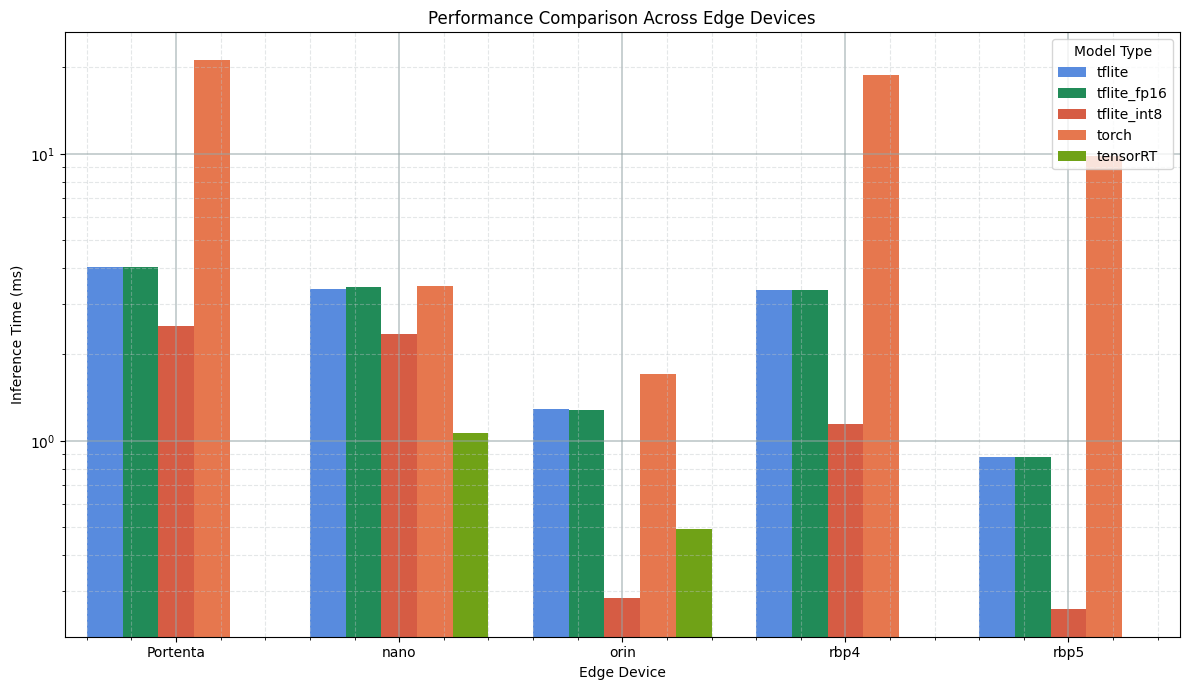

In [125]:
# 브랜드 색상 팔레트 정의
# 순서: ['tflite_fp16', 'tflite_int8', 'torch', 'tflite', 'tensorRT']
brand_colors = {
    'tflite_fp16': '#4285F4',    # Google Blue (TensorFlow Lite)
    'tflite_int8': '#0F9D58',    # Google Green (TensorFlow Lite quantized)
    'torch': '#EE4C2C',          # PyTorch Orange
    'tflite': '#FF6B35',         # Orange Red
    'tensorRT': '#76B900'        # NVIDIA Green
}

# 순서에 맞게 색상 리스트 생성
model_order = ['tflite_fp16', 'tflite_int8', 'torch', 'tflite', 'tensorRT']
custom_colors = [brand_colors[model] for model in model_order]

# 기본 차트 생성
fig, ax = plt.subplots(figsize=(12, 7))

# 바 차트 생성 (브랜드 색상 적용)
sns.barplot(data=df_plot, x='Device', y='Inference_Time_ms', hue='Model_Type', 
           ax=ax, palette=custom_colors)

# 기본 설정
ax.set_title('Performance Comparison Across Edge Devices')
ax.set_ylabel('Inference Time (ms)')
ax.set_xlabel('Edge Device')
ax.set_yscale('log')

# 그리드 추가 (major와 minor)
ax.minorticks_on()
ax.grid(True, which='major', alpha=0.6, linestyle='-', linewidth=1.2, color='#95A5A6')
ax.grid(True, which='minor', alpha=0.4, linestyle='--', linewidth=0.8, color='#BDC3C7')

# 범례
ax.legend(title='Model Type', loc='upper right')

plt.tight_layout()
plt.show()

In [126]:
cfg = Config(height=70, num_users=6, num_samples=10000)

df_ls = data_dict['orin']

obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')

df_ls.keys()

dict_keys(['orin_tensorRT.csv', 'orin_tflite.csv', 'orin_tflite_fp16.csv', 'orin_tflite_int8.csv', 'orin_torch.csv'])

In [127]:
torch.tensor(df_ls['orin_tensorRT.csv'].iloc[:, cfg.num_users * 2:cfg.num_users * 2 + 3].values, dtype=torch.float32).to(cfg.device)

tensor([[-30.9790, -82.0127,  70.0000],
        [-49.1539, 100.0000,  70.0000],
        [ 56.4660, -74.9661,  70.0000],
        ...,
        [-42.6665, 100.0000,  70.0000],
        [-45.6144, -81.6580,  70.0000],
        [-45.2851, -66.1735,  70.0000]], device='mps:0')

In [131]:
results_dic = {}
for key in df_ls.keys():
    df = df_ls[key]
    data = torch.tensor(df.iloc[:, :cfg.num_users * 2].values.reshape(-1, cfg.num_users, 2), dtype=torch.float32).to(cfg.device)
    gus = torch.cat((data, (torch.ones((data.shape[0], cfg.num_users), dtype=torch.float32, device=cfg.device) * cfg.height).unsqueeze(-1)), dim=-1).to(cfg.device)
    y = torch.tensor(df.iloc[:, cfg.num_users * 2:cfg.num_users * 2 + 3].values, dtype=torch.float32).to(cfg.device)
    
    result = 0
    for i in trange(len(gus)):
        result += calc_sig_strength_gpu(y[i].unsqueeze(0), gus[i], obst_tensor, cfg)

    result /= len(gus)
    results_dic[key] = result.cpu().numpy()

100%|██████████| 10000/10000 [00:08<00:00, 1210.59it/s]


In [132]:
results_dic

{'orin_tensorRT.csv': array([13.532826], dtype=float32),
 'orin_tflite.csv': array([13.533391], dtype=float32),
 'orin_tflite_fp16.csv': array([13.533438], dtype=float32),
 'orin_tflite_int8.csv': array([13.509859], dtype=float32),
 'orin_torch.csv': array([13.533391], dtype=float32)}